In [1]:
!pip install statsforecast


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [23]:
import pandas as pd
import numpy as np
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoARIMA, AutoETS
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape, bias


In [25]:
df = pd.read_parquet('/work/sample_hotels-1.parquet')
df['ds'] = pd.to_datetime(df['ds'])

In [27]:
otb_cols = [f'otb_{i}' for i in range(28, 61) if f'otb_{i}' in df.columns]
df = df.query("unique_id not in ['hotel_77', 'hotel_28']")


In [29]:
test_df = df.groupby('unique_id').tail(28).reset_index(drop=True)
train_df = df.groupby('unique_id').apply(lambda x: x.iloc[:-28]).reset_index(drop=True)


In [31]:
train_df_dummies = pd.get_dummies(train_df, columns=['location_type', 'hotel_type'], dtype=float)
dummies = [c for c in train_df_dummies if 'location_type_' in c or 'hotel_type_' in c]
predictor_cols = otb_cols + dummies

In [33]:
sf_no_pred = StatsForecast(
    models=[Naive(), SeasonalNaive(7), AutoETS(7), AutoARIMA(season_length = 7, alias='AutoARIMA_NoPred')], 
    freq='D', n_jobs=-1
)

cv_no_pred = sf_no_pred.cross_validation(
    df=train_df[['unique_id', 'ds', 'y']], 
    h=28, 
    n_windows=5, 
    step_size=28
    )


In [34]:
sf_with_pred = StatsForecast(
    models=[AutoARIMA(season_length=7, alias='AutoARIMA_WithPred')], 
    freq='D', 
    n_jobs=-1
)

key_predictors = ['otb_28'] + dummies

cv_with_pred = sf_with_pred.cross_validation(
    df=train_df_dummies[['unique_id', 'ds', 'y'] + key_predictors], 
    h=28, 
    n_windows=5, 
    step_size=28
)

In [39]:
combined_cv = cv_no_pred.merge(
    cv_with_pred.drop(columns='y'), 
    on=['unique_id', 'ds', 'cutoff']
)

final_results = evaluate(
    combined_cv.drop(columns='cutoff'),
    metrics=[mae, rmse, mape, bias],
    models=['Naive', 'SeasonalNaive', 'AutoETS', 'AutoARIMA_NoPred', 'AutoARIMA_WithPred']
)

final_summary = (
    final_results
    .groupby(['unique_id', 'metric'])
    .mean(numeric_only=True)
    .reset_index()
)

display(final_summary)

,unique_id,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA_NoPred,AutoARIMA_WithPred
0,hotel_0,bias,0.091005,0.012346,0.000761,0.024971,-0.008726
1,hotel_0,mae,0.199118,0.211640,0.178667,0.184751,0.153937
2,hotel_0,mape,0.347360,0.338512,0.284501,0.303490,0.237407
3,hotel_0,rmse,0.254397,0.264057,0.223475,0.233278,0.188797
4,hotel_105,bias,0.140476,-0.063657,-0.021002,-0.021193,0.008844
...,...,...,...,...,...,...,...
63,hotel_91,rmse,0.245749,0.245353,0.212522,0.199046,0.169465
64,hotel_98,bias,0.093203,0.024078,0.016818,0.005322,-0.059928
65,hotel_98,mae,0.190323,0.148387,0.147137,0.115015,0.125626
66,hotel_98,mape,1.124043,0.731191,0.724431,0.578616,0.573872


In [49]:
stat_models = ['Naive', 'SeasonalNaive', 'AutoETS', 'AutoARIMA_NoPred', 'AutoARIMA_WithPred']

# 2. Calculate the winner for every hotel/metric row
# This identifies the model with the lowest error value for each row
final_summary['winner'] = final_summary[stat_models].idxmin(axis=1)


In [58]:
# 3. Create the Summary Table: Count how often each model wins on each metric
# This satisfies the requirement: "A summary table counting how often each model wins on each metric"
stat_win_counts = (
    final_summary
    .groupby(['metric', 'winner'])
    .size()
    .reset_index(name='wins')
)

print("--- Statistical Model Win Count Summary ---")
display(stat_win_counts)

--- Statistical Model Win Count Summary ---


,metric,winner,wins
0,bias,AutoARIMA_NoPred,4
1,bias,AutoARIMA_WithPred,4
2,bias,AutoETS,6
3,bias,Naive,1
4,bias,SeasonalNaive,2
5,mae,AutoARIMA_NoPred,2
6,mae,AutoARIMA_WithPred,12
7,mae,Naive,2
8,mae,SeasonalNaive,1
9,mape,AutoARIMA_NoPred,1


In [60]:
sf_no_pred.fit(train_df[['unique_id', 'ds', 'y']])
forecast_no_pred = sf_no_pred.predict(h=28)

In [64]:
# get the full test rows including predictors from original df
test_df_with_pred = (
    df.groupby('unique_id')
    .tail(28)
    .reset_index(drop=True)
)
test_df_with_pred = pd.get_dummies(test_df_with_pred, columns=['location_type', 'hotel_type'], dtype=float)

# now predict
sf_with_pred.fit(train_df_dummies[['unique_id', 'ds', 'y'] + key_predictors])
forecast_with_pred = sf_with_pred.predict(
    h=28,
    X_df=test_df_with_pred[['unique_id', 'ds'] + key_predictors]
)

In [66]:
# combine forecasts
forecast_combined = forecast_no_pred.merge(
    forecast_with_pred,
    on=['unique_id', 'ds']
)

results_test_sf = forecast_combined.merge(test_df[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'])

eval_test_sf = evaluate(
    df=results_test_sf,
    metrics=[bias, mae, rmse, mape],
    models=stat_models
)
display(eval_test_sf)


,unique_id,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA_NoPred,AutoARIMA_WithPred
0,hotel_0,bias,-0.041887,-0.168871,-0.199668,-0.108068,-0.113278
1,hotel_105,bias,-0.047619,-0.046721,-0.069356,-0.079980,0.040338
2,hotel_112,bias,-0.119866,0.003348,-0.040603,-0.017935,0.013225
3,hotel_126,bias,0.005407,-0.036141,-0.052891,-0.016760,-0.007902
4,hotel_133,bias,0.033958,-0.005855,-0.012568,-0.035287,-0.025359
...,...,...,...,...,...,...,...
63,hotel_7,mape,0.716212,0.514262,0.464475,0.281535,0.205548
64,hotel_70,mape,0.128150,0.288243,0.174306,0.091303,0.294618
65,hotel_84,mape,0.108934,0.163925,0.131341,0.116339,0.100781
66,hotel_91,mape,0.093757,0.152336,0.072534,0.079184,0.075558


In [68]:
# save to csv
eval_test_sf.to_csv('statsforecast_test_eval.csv', index=False)
results_test_sf.to_csv('statsforecast_test_forecasts.csv', index=False)


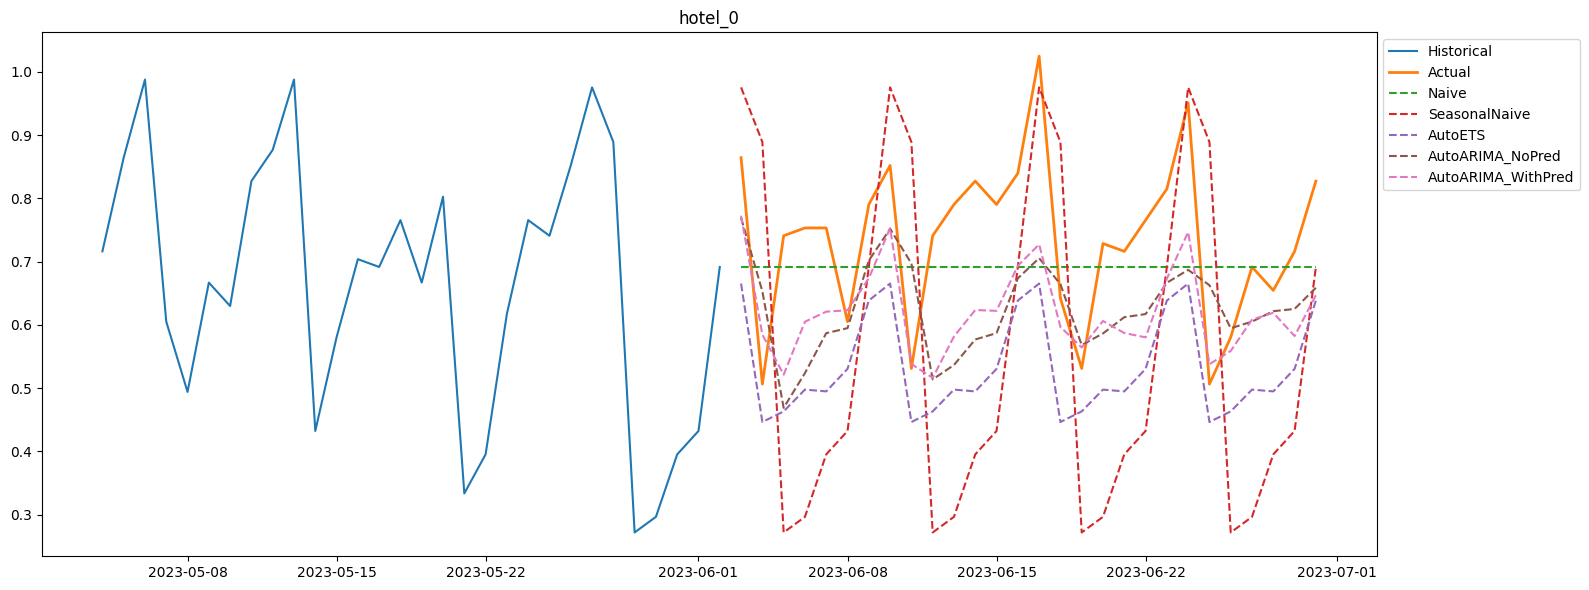

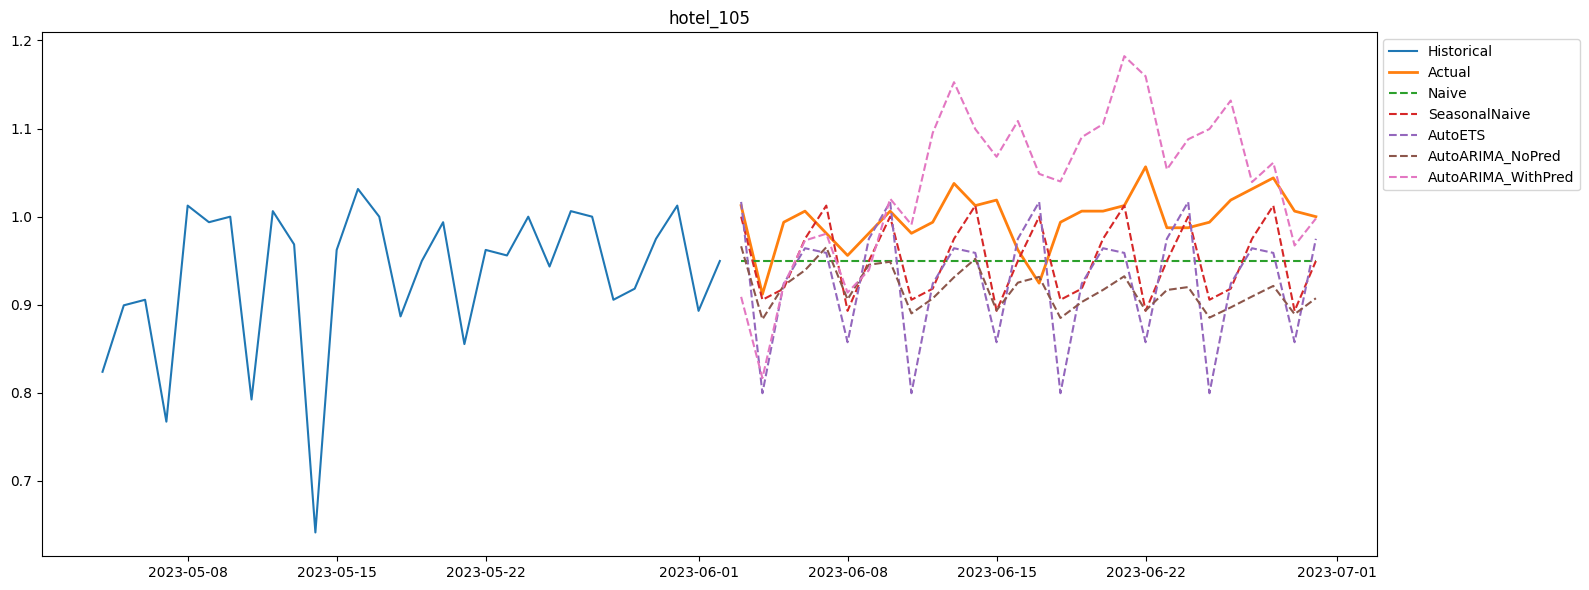

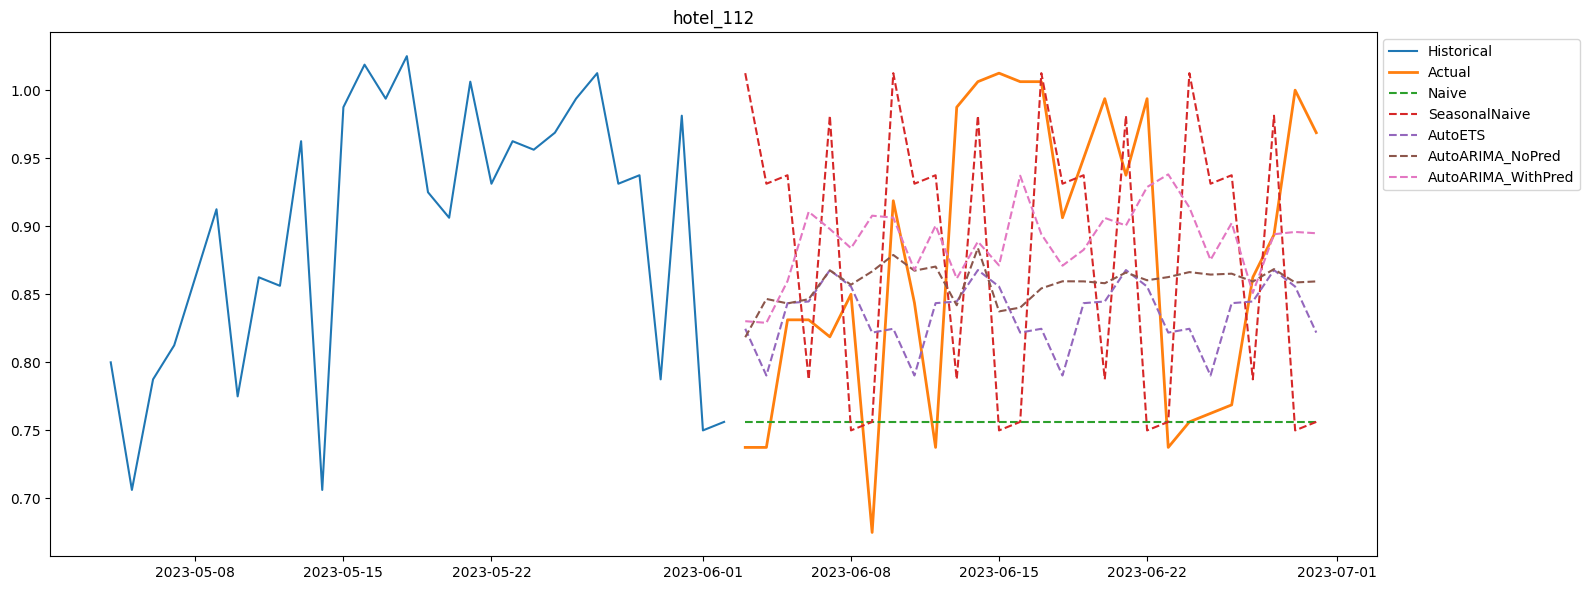

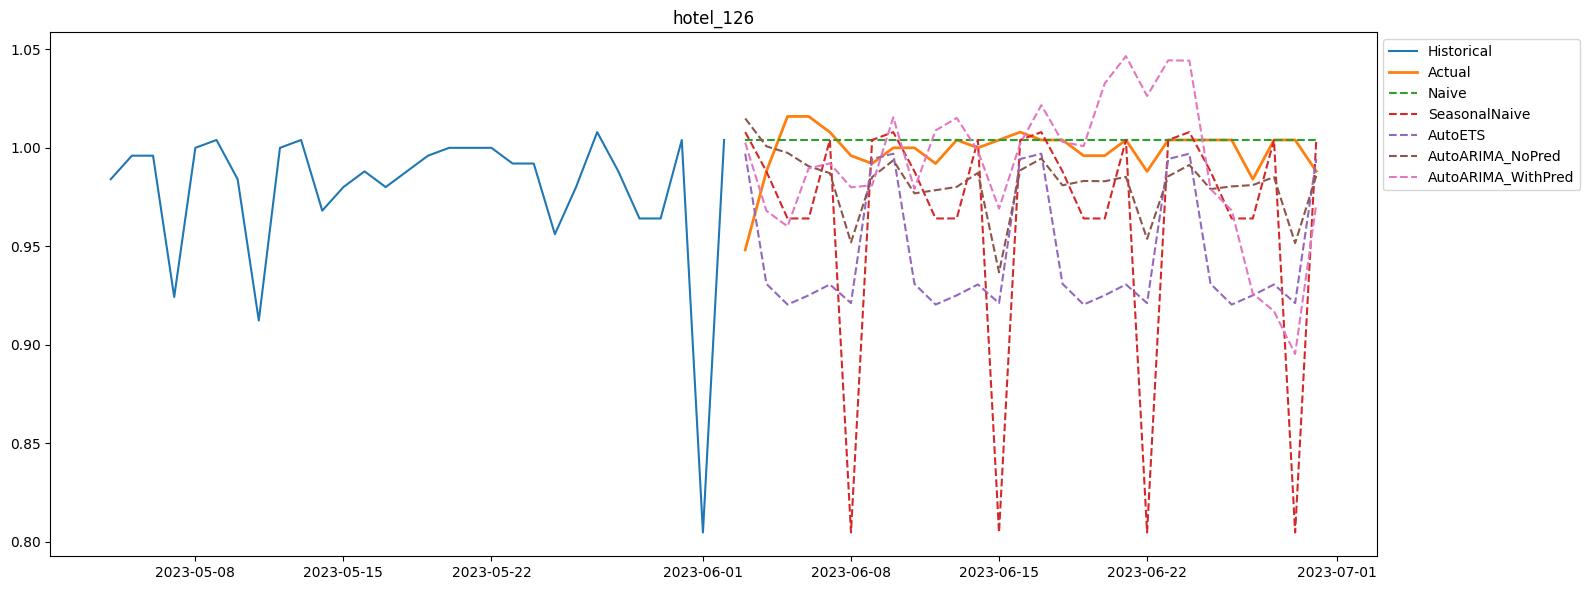

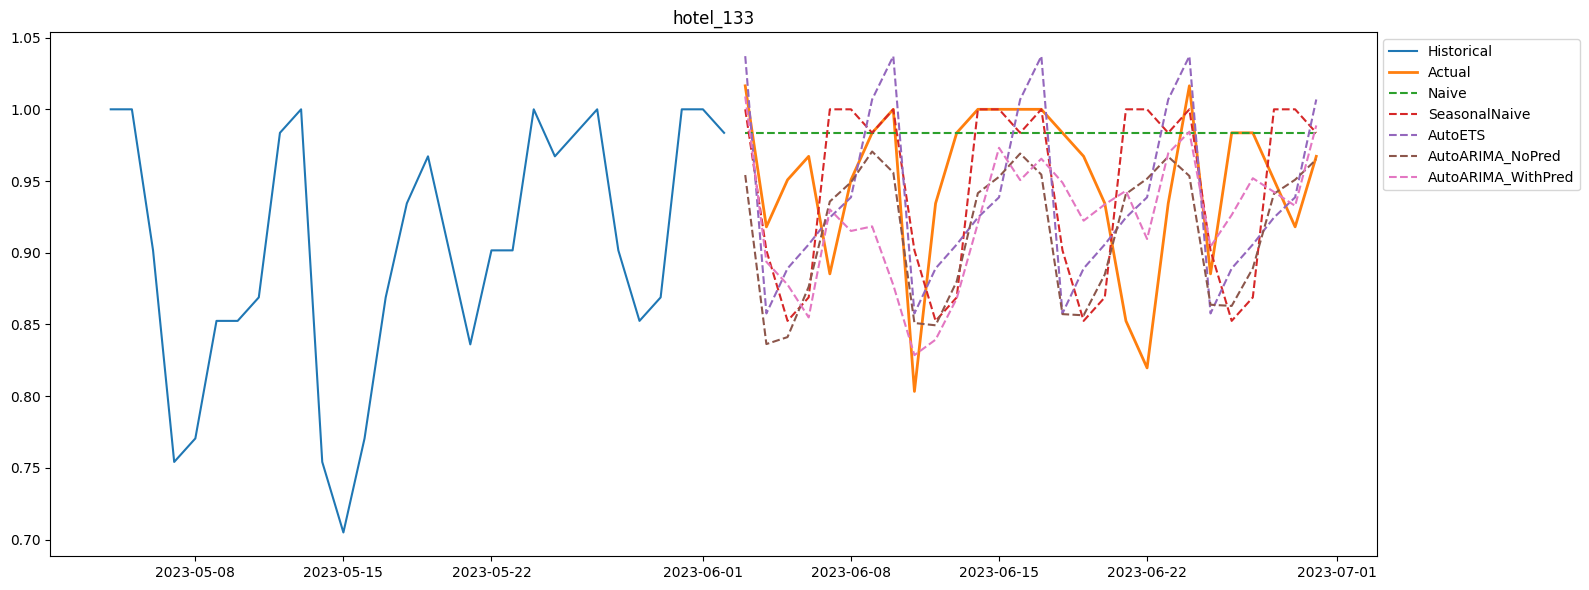

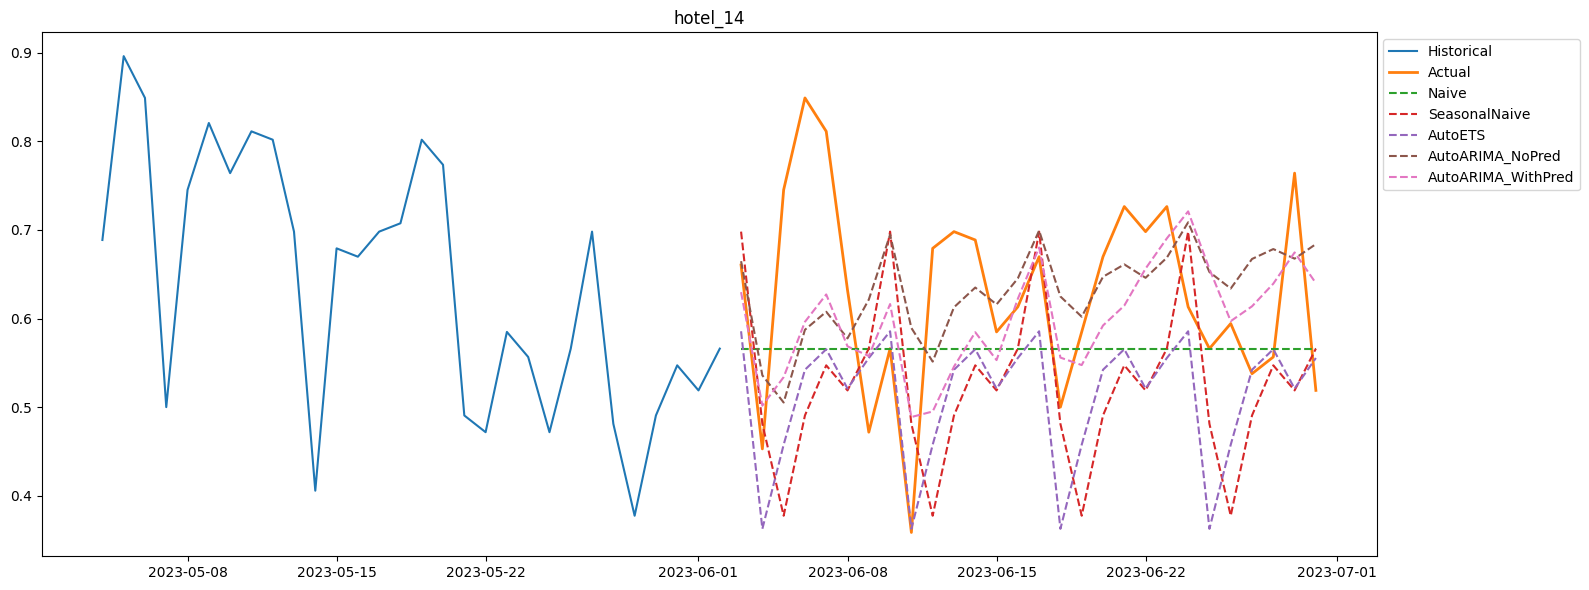

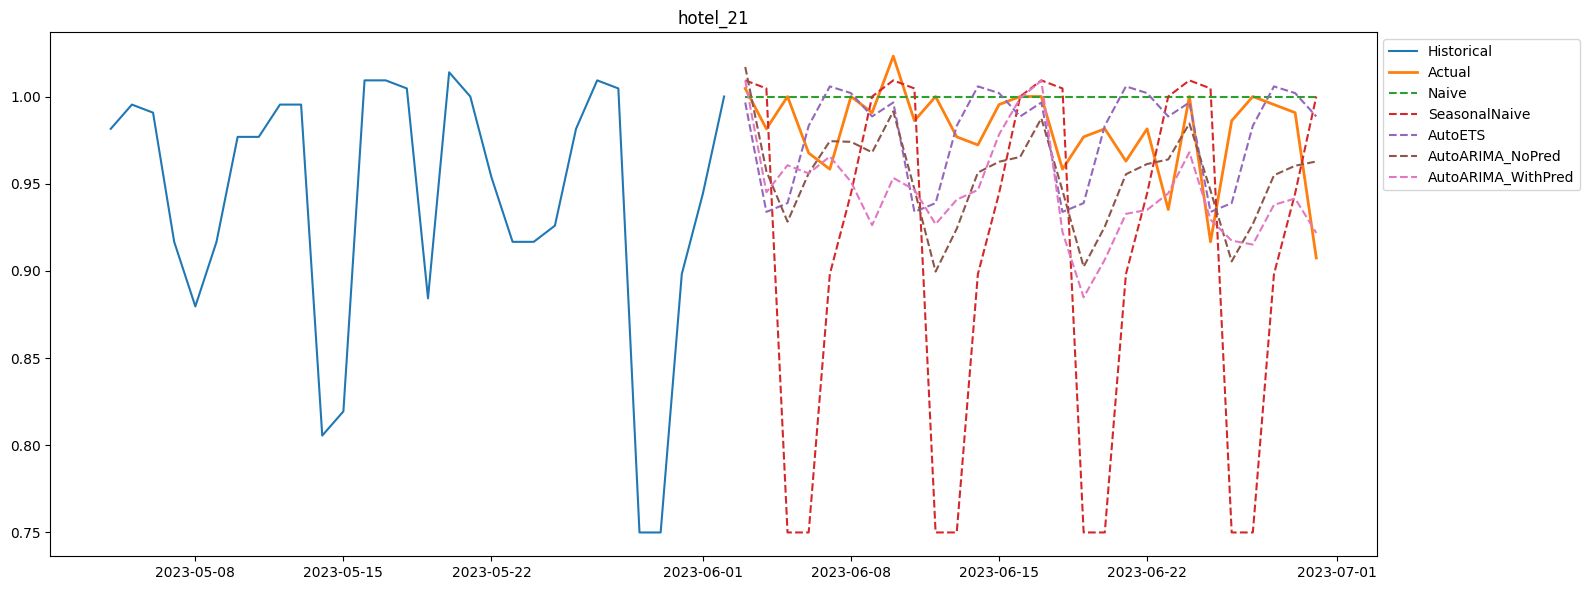

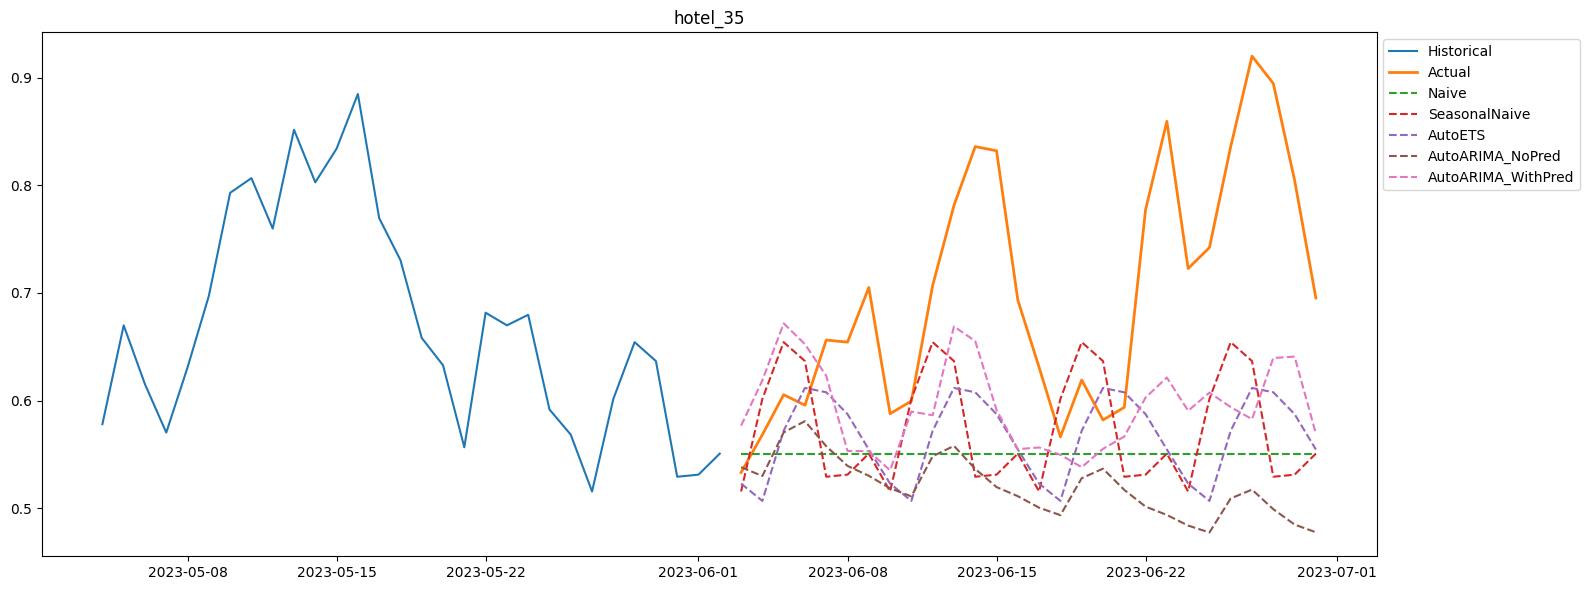

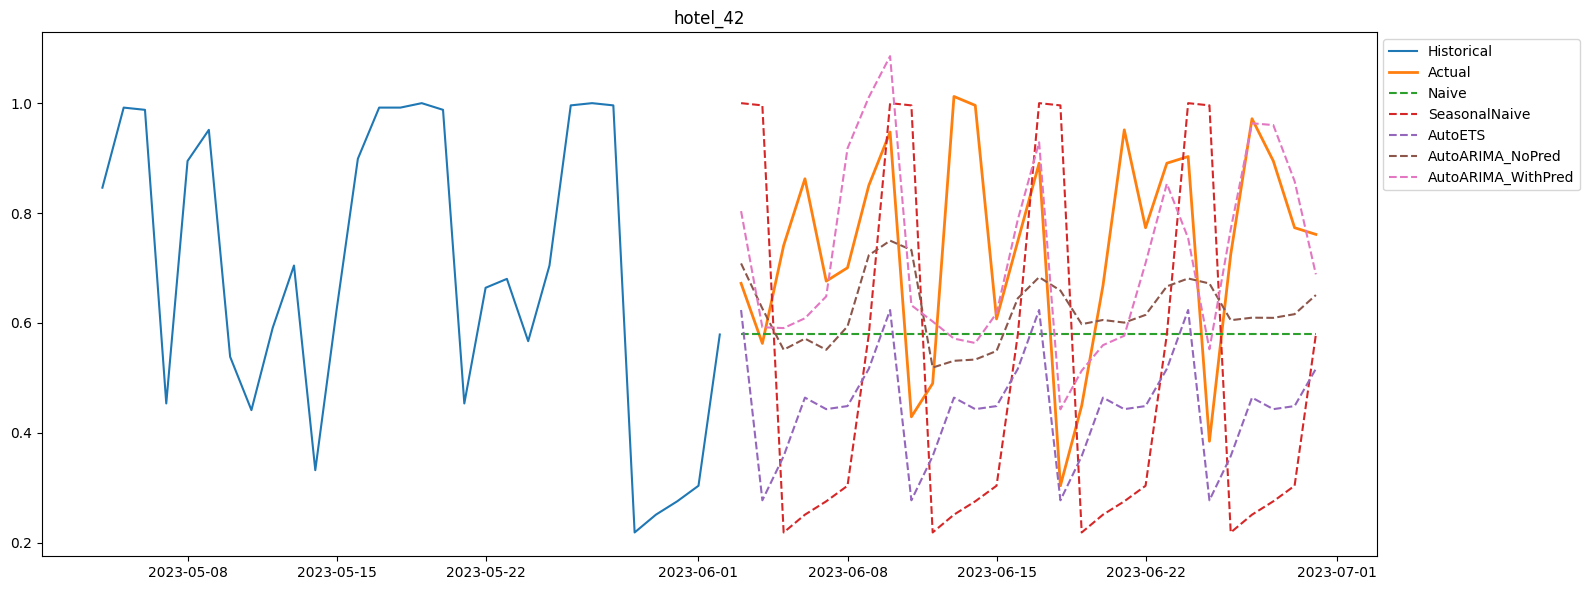

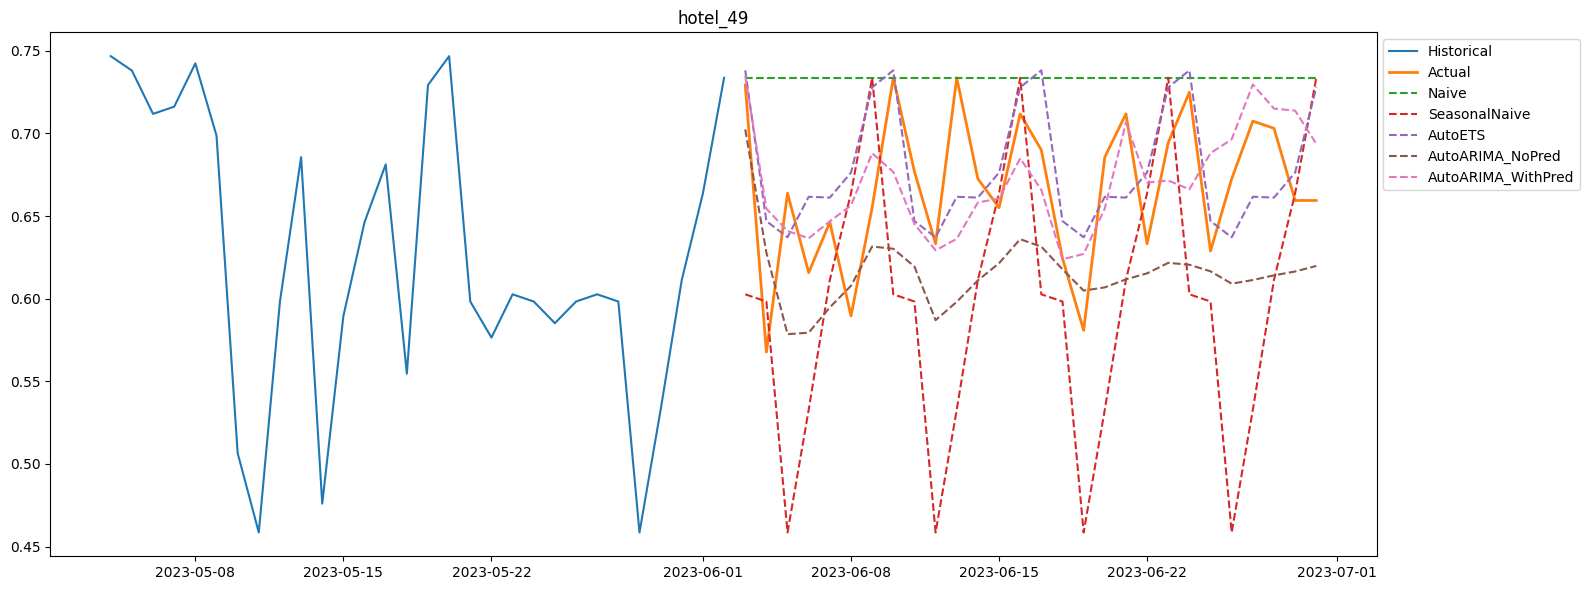

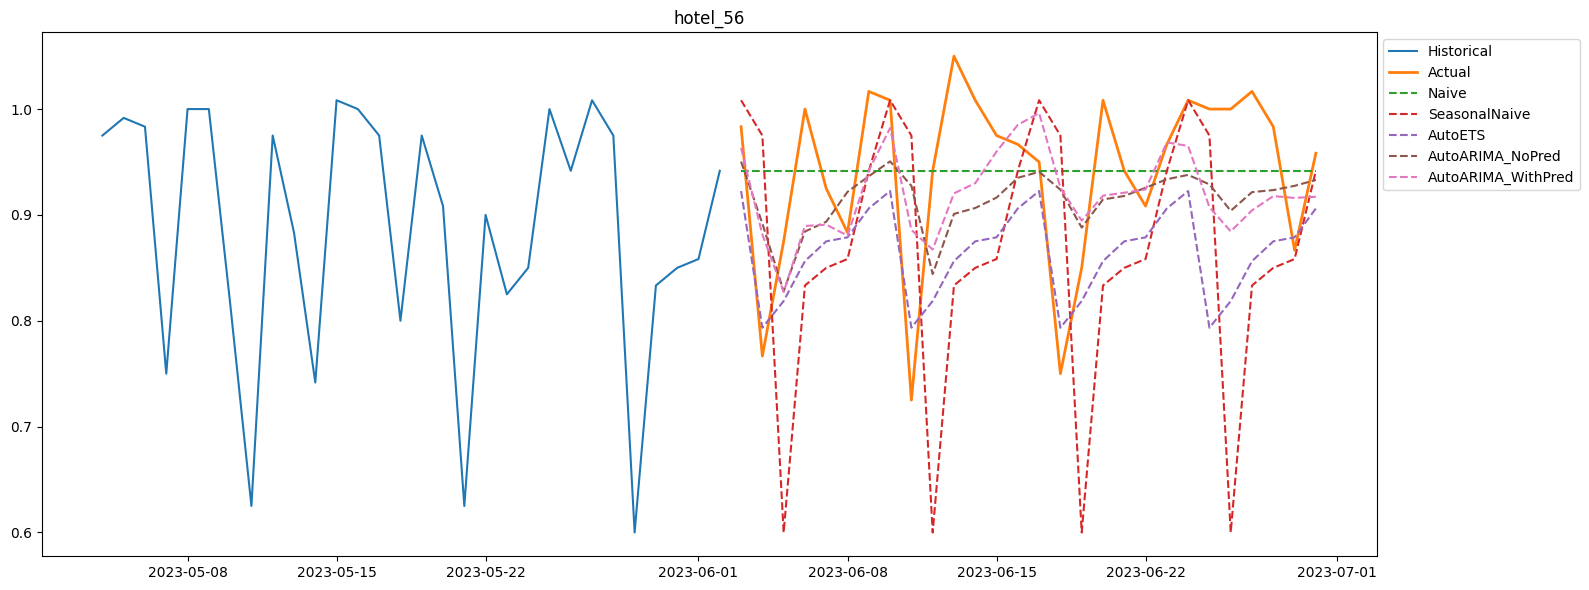

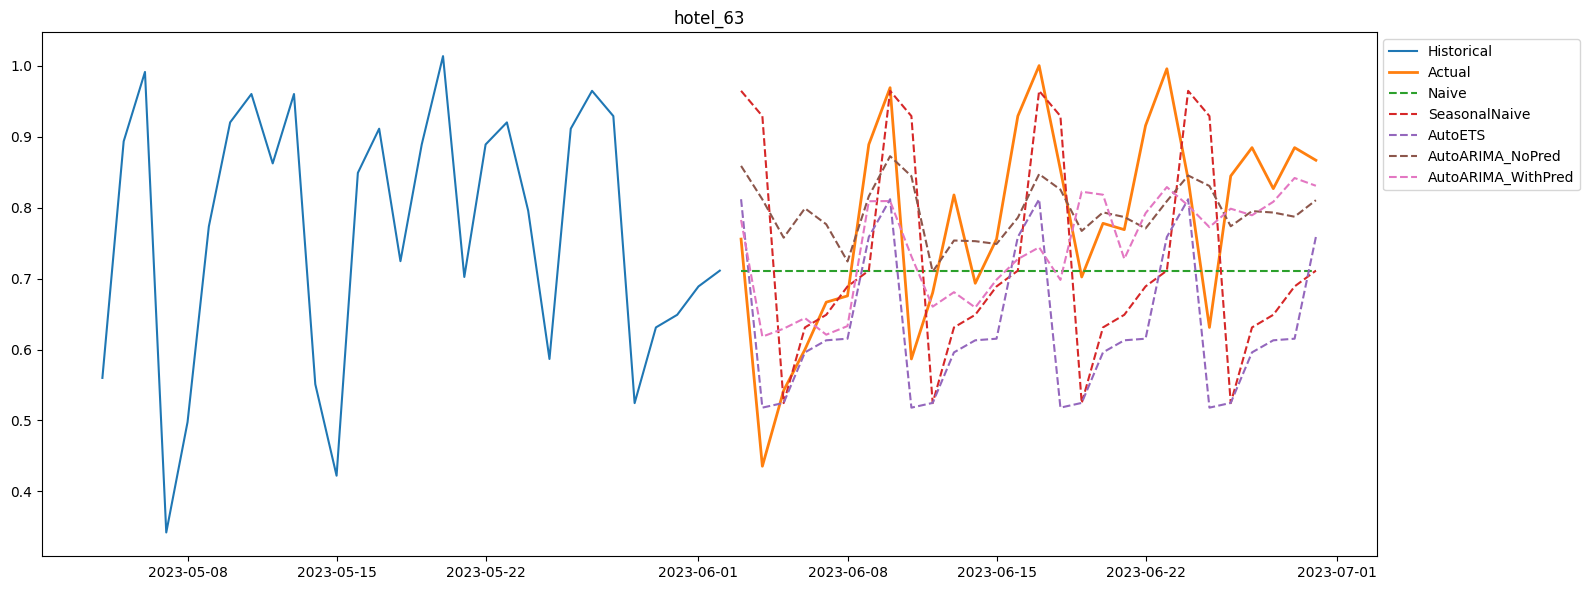

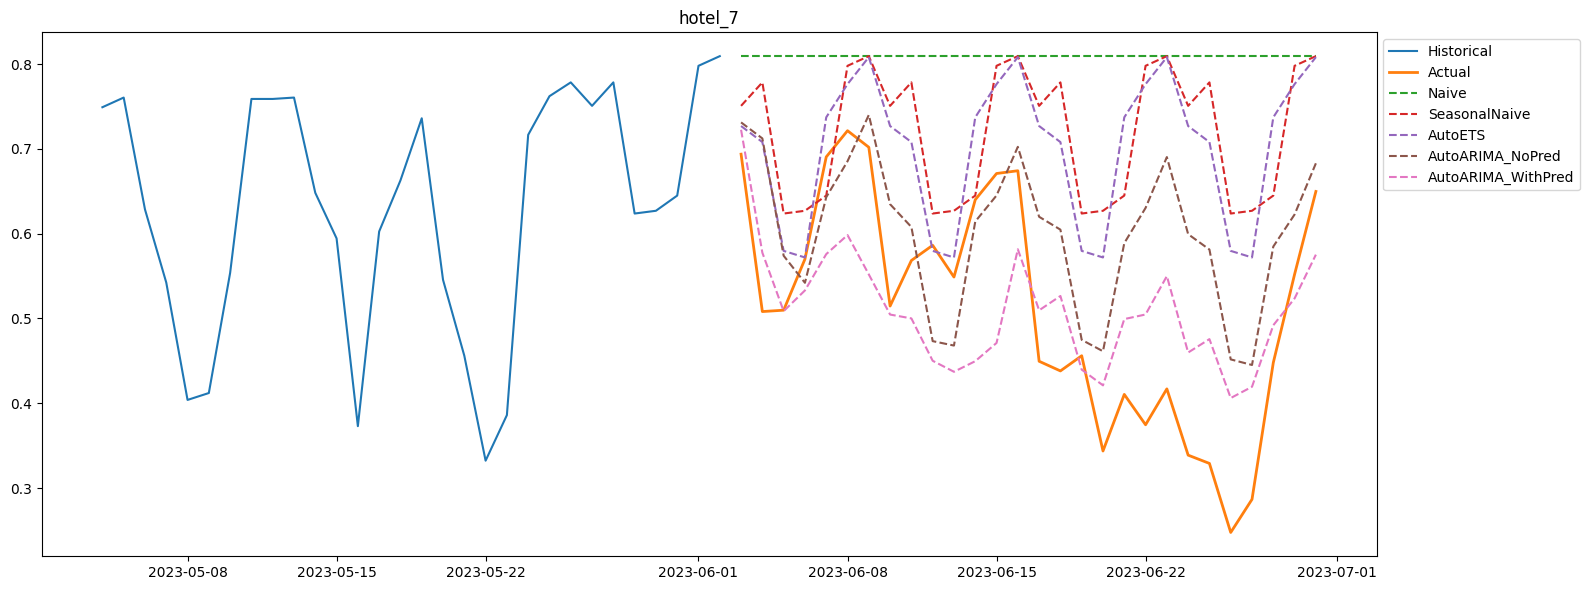

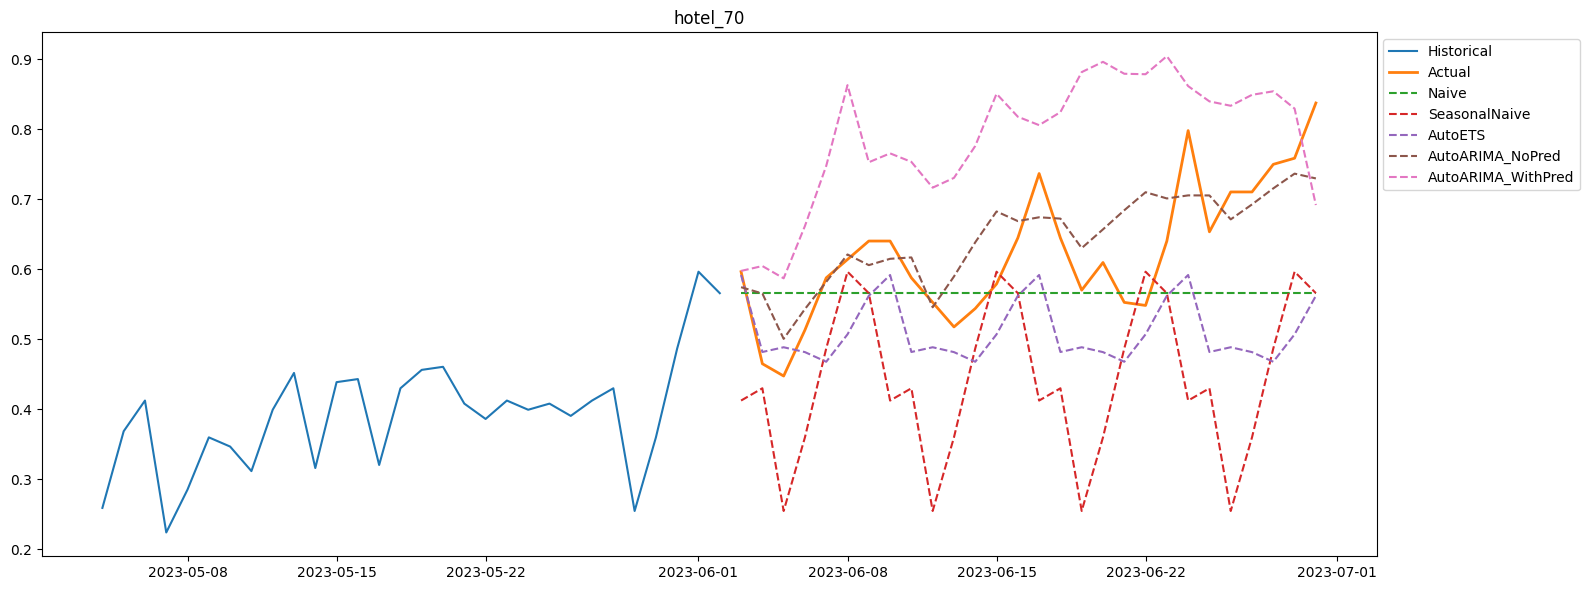

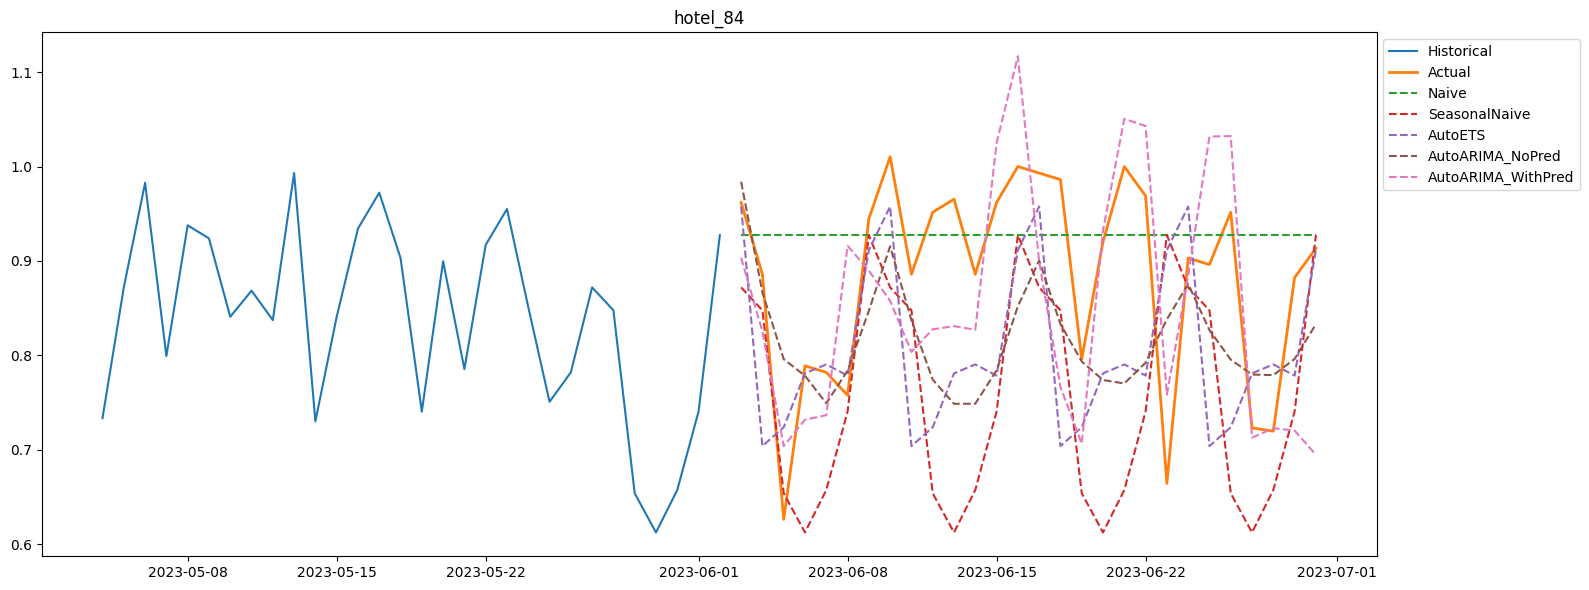

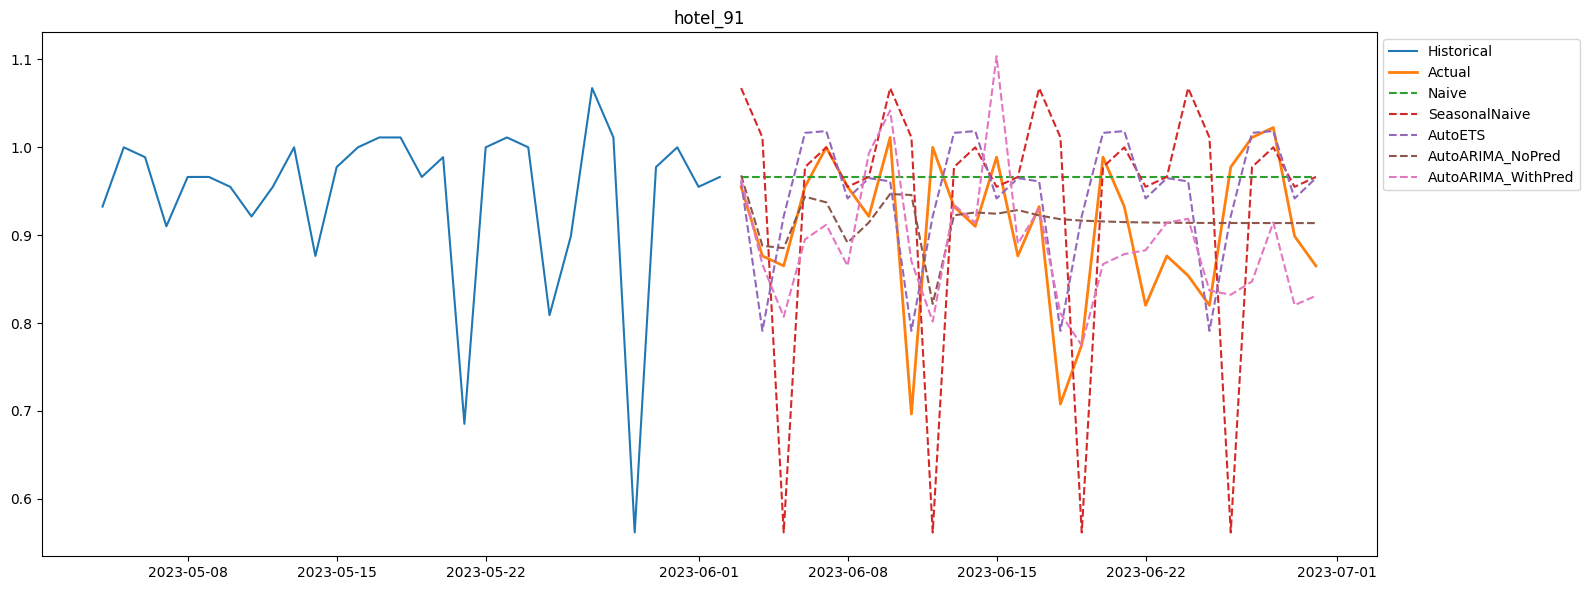

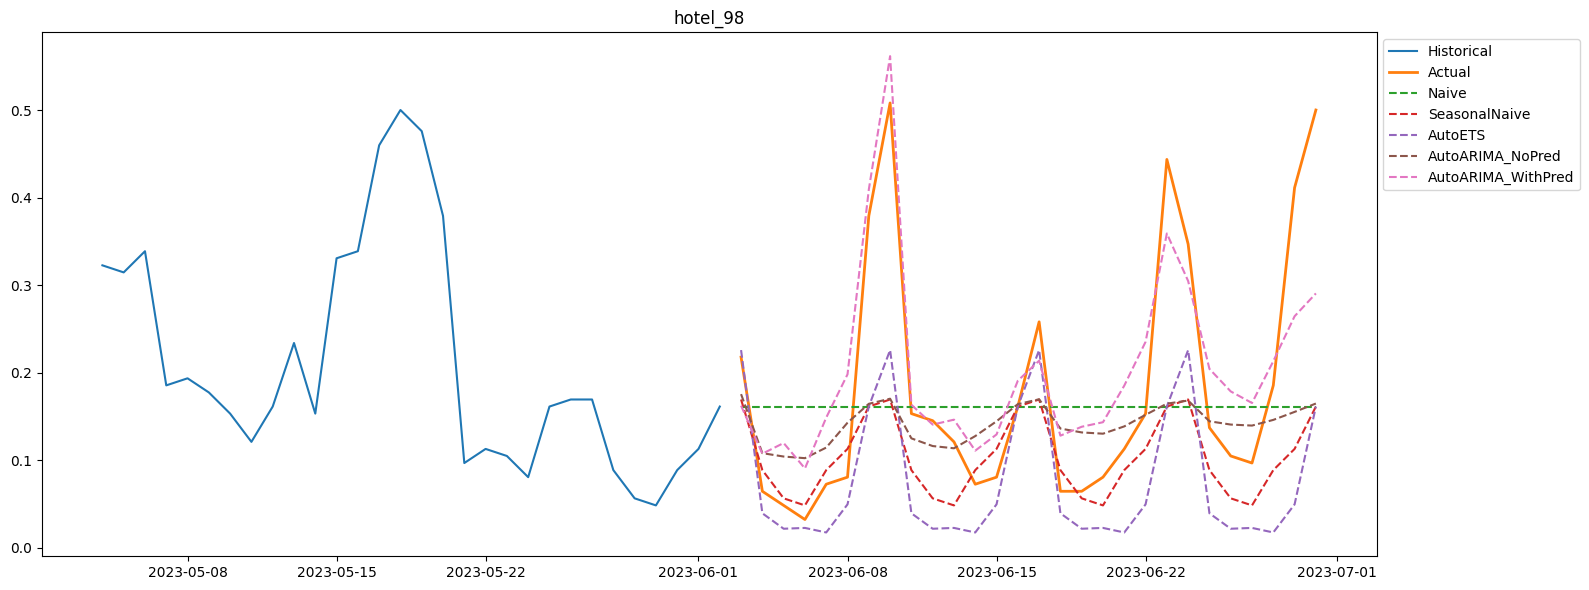

In [74]:
import matplotlib.pyplot as plt

for hotel_id in results_test_sf['unique_id'].unique():
    actual  = test_df[test_df['unique_id'] == hotel_id]
    preds   = results_test_sf[results_test_sf['unique_id'] == hotel_id]
    history = train_df[train_df['unique_id'] == hotel_id].tail(30)

    plt.figure(figsize=(16, 6))
    plt.plot(history['ds'], history['y'], label='Historical')
    plt.plot(actual['ds'], actual['y'], label='Actual', linewidth=2)
    for model in stat_models:
        plt.plot(preds['ds'], preds[model], label=model, linestyle='--')
    plt.title(hotel_id)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=94252149-99d5-4a3a-8951-54d7f526c43a' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>